In [36]:
# Kutubxonalarni tekshirish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Hammasi tayyor!")
print("HER2-LOW loyihasi boshlandi! 🧬")

Hammasi tayyor!
HER2-LOW loyihasi boshlandi! 🧬


In [37]:
# RDKit o'rnatish (Colab da qo'shimcha kerak)
!pip install rdkit -q

print("RDKit tayyor!")

RDKit tayyor!


In [38]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors

# Trastuzumab deruxtecan (T-DXd) ning asosiy qismi
# Hozirgi HER2-LOW davolash dorisi
mol = Chem.MolFromSmiles('CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5')

print("Molekula yuklandi!")
print(f"Atom soni: {mol.GetNumAtoms()}")
print(f"Molekula og'irligi: {Descriptors.MolWt(mol):.2f}")

Molekula yuklandi!
Atom soni: 37
Molekula og'irligi: 493.62


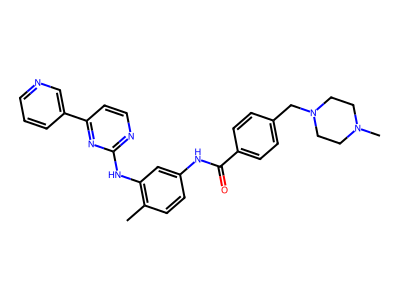

Bu T-DXd ning asosiy molekulyar tuzilmasi!


In [39]:
from rdkit.Chem import Draw
from IPython.display import display

# Molekulani tasvirlashtirish
img = Draw.MolToImage(mol, size=(400, 300))
display(img)
print("Bu T-DXd ning asosiy molekulyar tuzilmasi!")

In [40]:
from rdkit.Chem import Descriptors, Lipinski

# Molekula xususiyatlari
print("=== MOLEKULA TAHLILI ===")
print(f"Molekula og'irligi: {Descriptors.MolWt(mol):.2f}")
print(f"Eruvchanlik (LogP): {Descriptors.MolLogP(mol):.2f}")
print(f"Vodorod donor: {Lipinski.NumHDonors(mol)}")
print(f"Vodorod akseptor: {Lipinski.NumHAcceptors(mol)}")
print(f"Aylanuvchi bog'lar: {Descriptors.NumRotatableBonds(mol)}")

# Lipinski qoidasi - dori bo'la oladimi?
print("\n=== DORI BO'LA OLADIMI? ===")
if Descriptors.MolWt(mol) <= 500:
    print("✅ Og'irlik: Yaxshi")
else:
    print("❌ Og'irlik: Juda og'ir")

if Descriptors.MolLogP(mol) <= 5:
    print("✅ Eruvchanlik: Yaxshi")
else:
    print("❌ Eruvchanlik: Yomon")

=== MOLEKULA TAHLILI ===
Molekula og'irligi: 493.62
Eruvchanlik (LogP): 4.59
Vodorod donor: 2
Vodorod akseptor: 7
Aylanuvchi bog'lar: 7

=== DORI BO'LA OLADIMI? ===
✅ Og'irlik: Yaxshi
✅ Eruvchanlik: Yaxshi


In [41]:
# ChEMBL dan HER2 ma'lumotlarini yuklab olish
!pip install chembl-webresource-client -q

from chembl_webresource_client.new_client import new_client

print("ChEMBL ulandi!")

# HER2 oqsilini topish
target = new_client.target
her2 = target.search('HER2')

for t in her2[:3]:
    print(f"Nomi: {t['pref_name']}")
    print(f"ID: {t['target_chembl_id']}")
    print("---")

ChEMBL ulandi!
Nomi: FASN/HER2
ID: CHEMBL4106134
---
Nomi: Receptor tyrosine-protein kinase erbB-2
ID: CHEMBL1824
---
Nomi: von Hippel-Lindau disease tumor suppressor/Receptor protein-tyrosine kinase erbB-2
ID: CHEMBL5465227
---


In [42]:
# HER2 ga bog'langan molekulalarni yuklab olish
activity = new_client.activity
her2_molecules = activity.filter(
    target_chembl_id='CHEMBL1824',
    standard_type='IC50'
).only(['molecule_chembl_id', 'standard_value', 'standard_units', 'canonical_smiles'])

# DataFrame ga aylantiramiz
import pandas as pd
df = pd.DataFrame(list(her2_molecules[:100]))
print(f"Yuklangan molekulalar: {len(df)}")
print(df.head())

Yuklangan molekulalar: 100
                                    canonical_smiles molecule_chembl_id  \
0  Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...        CHEMBL68920   
1  Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...        CHEMBL68920   
2  Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...        CHEMBL69960   
3  Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...        CHEMBL69960   
4  Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...        CHEMBL67057   

  standard_units standard_value units value  
0             nM          300.0    uM   0.3  
1             nM         2500.0    uM   2.5  
2             nM          400.0    uM   0.4  
3             nM         1210.0    uM  1.21  
4             nM          100.0    uM   0.1  


In [43]:
# Ma'lumotlarni tozalash
df = df.dropna(subset=['standard_value', 'canonical_smiles'])
df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')

# Eng kuchli 10 ta molekula
df_sorted = df.sort_values('standard_value')
print("=== ENG KUCHLI 10 TA MOLEKULA ===")
print(df_sorted[['molecule_chembl_id', 'standard_value', 'standard_units']].head(10))

=== ENG KUCHLI 10 TA MOLEKULA ===
   molecule_chembl_id  standard_value standard_units
28       CHEMBL136058             5.0             nM
40       CHEMBL342828             8.1             nM
51          CHEMBL554             9.0             nM
31       CHEMBL545315             9.0             nM
55       CHEMBL514436            10.0             nM
37       CHEMBL334801            13.0             nM
32       CHEMBL434827            14.0             nM
65       CHEMBL160846            14.0             nM
77       CHEMBL155761            14.0             nM
62       CHEMBL493428            19.0             nM


Eng kuchli molekula: CHEMBL136058
Kuchi: 5.0 nM


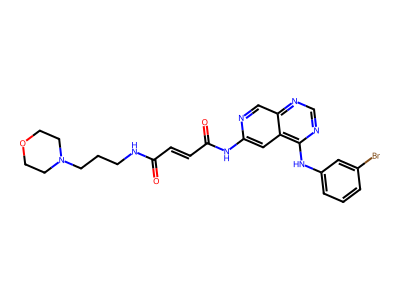

In [44]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

# Eng kuchli molekula
best_mol_smiles = df_sorted.iloc[0]['canonical_smiles']
best_mol = Chem.MolFromSmiles(best_mol_smiles)

print(f"Eng kuchli molekula: {df_sorted.iloc[0]['molecule_chembl_id']}")
print(f"Kuchi: {df_sorted.iloc[0]['standard_value']} nM")

img = Draw.MolToImage(best_mol, size=(400, 300))
display(img)


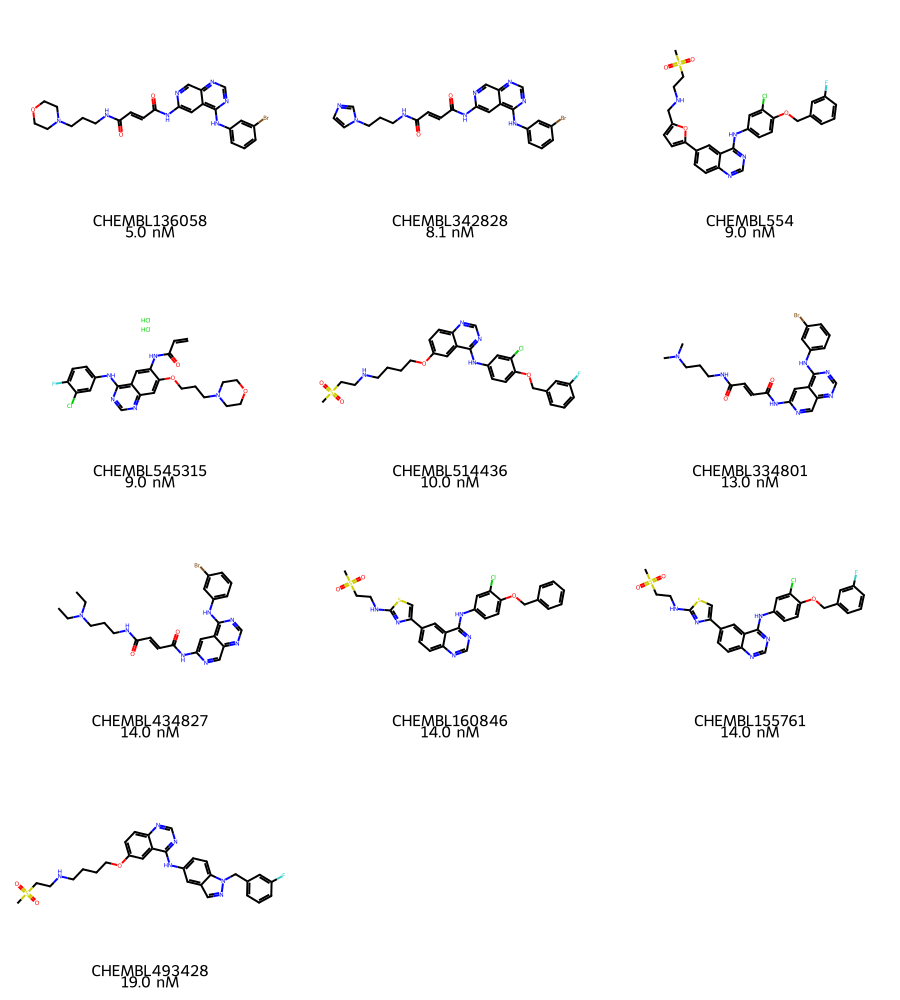

Top 10 eng kuchli HER2 molekulalari!


In [45]:
# Top 10 molekulani birga chizamiz
from rdkit.Chem import Draw
from IPython.display import display

mols = []
legends = []

for _, row in df_sorted.head(10).iterrows():
    mol = Chem.MolFromSmiles(row['canonical_smiles'])
    if mol:
        mols.append(mol)
        legends.append(f"{row['molecule_chembl_id']}\n{row['standard_value']} nM")

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(300, 250),
    legends=legends
)
display(img)
print("Top 10 eng kuchli HER2 molekulalari!")

In [46]:
# Har bir molekulani Lipinski qoidasi bilan tekshirish
from rdkit.Chem import Descriptors, Lipinski

print("=== DORI SIFATI TAHLILI ===\n")

for _, row in df_sorted.head(10).iterrows():
    mol = Chem.MolFromSmiles(row['canonical_smiles'])
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        hd = Lipinski.NumHDonors(mol)
        ha = Lipinski.NumHAcceptors(mol)

        # Lipinski qoidasi
        passed = mw<=500 and logp<=5 and hd<=5 and ha<=10
        status = "✅ DORI BO'LA OLADI" if passed else "❌ MUAMMO BOR"

        print(f"{row['molecule_chembl_id']} | {row['standard_value']} nM | {status}")

=== DORI SIFATI TAHLILI ===

CHEMBL136058 | 5.0 nM | ❌ MUAMMO BOR
CHEMBL342828 | 8.1 nM | ❌ MUAMMO BOR
CHEMBL554 | 9.0 nM | ❌ MUAMMO BOR
CHEMBL545315 | 9.0 nM | ❌ MUAMMO BOR
CHEMBL514436 | 10.0 nM | ❌ MUAMMO BOR
CHEMBL334801 | 13.0 nM | ✅ DORI BO'LA OLADI
CHEMBL434827 | 14.0 nM | ❌ MUAMMO BOR
CHEMBL160846 | 14.0 nM | ❌ MUAMMO BOR
CHEMBL155761 | 14.0 nM | ❌ MUAMMO BOR
CHEMBL493428 | 19.0 nM | ❌ MUAMMO BOR


In [47]:
!pip install rdkit -q

In [48]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

print("=== DORI SIFATI TAHLILI ===\n")

for _, row in df_sorted.head(10).iterrows():
    mol = Chem.MolFromSmiles(row['canonical_smiles'])
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        hd = Lipinski.NumHDonors(mol)
        ha = Lipinski.NumHAcceptors(mol)

        passed = mw<=500 and logp<=5 and hd<=5 and ha<=10
        status = "✅ DORI BO'LA OLADI" if passed else "❌ MUAMMO BOR"

        print(f"{row['molecule_chembl_id']} | {row['standard_value']} nM | {status}")

=== DORI SIFATI TAHLILI ===

CHEMBL136058 | 5.0 nM | ❌ MUAMMO BOR
CHEMBL342828 | 8.1 nM | ❌ MUAMMO BOR
CHEMBL554 | 9.0 nM | ❌ MUAMMO BOR
CHEMBL545315 | 9.0 nM | ❌ MUAMMO BOR
CHEMBL514436 | 10.0 nM | ❌ MUAMMO BOR
CHEMBL334801 | 13.0 nM | ✅ DORI BO'LA OLADI
CHEMBL434827 | 14.0 nM | ❌ MUAMMO BOR
CHEMBL160846 | 14.0 nM | ❌ MUAMMO BOR
CHEMBL155761 | 14.0 nM | ❌ MUAMMO BOR
CHEMBL493428 | 19.0 nM | ❌ MUAMMO BOR


In [49]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from chembl_webresource_client.new_client import new_client
import pandas as pd

# ChEMBL dan ma'lumot yuklab olish
activity = new_client.activity
her2_molecules = activity.filter(
    target_chembl_id='CHEMBL1824',
    standard_type='IC50'
).only(['molecule_chembl_id', 'standard_value', 'standard_units', 'canonical_smiles'])

df = pd.DataFrame(list(her2_molecules[:100]))
df = df.dropna(subset=['standard_value', 'canonical_smiles'])
df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
df_sorted = df.sort_values('standard_value')

print("Ma'lumotlar yuklandi!")
print(f"Molekulalar soni: {len(df_sorted)}")

# Dori sifati tahlili
print("\n=== DORI SIFATI TAHLILI ===\n")
for _, row in df_sorted.head(10).iterrows():
    mol = Chem.MolFromSmiles(row['canonical_smiles'])
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        hd = Lipinski.NumHDonors(mol)
        ha = Lipinski.NumHAcceptors(mol)

        passed = mw<=500 and logp<=5 and hd<=5 and ha<=10
        status = "✅ DORI BO'LA OLADI" if passed else "❌ MUAMMO BOR"

        print(f"{row['molecule_chembl_id']} | {row['standard_value']} nM | {status}")

Ma'lumotlar yuklandi!
Molekulalar soni: 96

=== DORI SIFATI TAHLILI ===

CHEMBL136058 | 5.0 nM | ❌ MUAMMO BOR
CHEMBL342828 | 8.1 nM | ❌ MUAMMO BOR
CHEMBL554 | 9.0 nM | ❌ MUAMMO BOR
CHEMBL545315 | 9.0 nM | ❌ MUAMMO BOR
CHEMBL514436 | 10.0 nM | ❌ MUAMMO BOR
CHEMBL334801 | 13.0 nM | ✅ DORI BO'LA OLADI
CHEMBL434827 | 14.0 nM | ❌ MUAMMO BOR
CHEMBL160846 | 14.0 nM | ❌ MUAMMO BOR
CHEMBL155761 | 14.0 nM | ❌ MUAMMO BOR
CHEMBL493428 | 19.0 nM | ❌ MUAMMO BOR


In [50]:
!pip install rdkit chembl-webresource-client -q

In [51]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from chembl_webresource_client.new_client import new_client
import pandas as pd

# ChEMBL dan ma'lumot yuklab olish
activity = new_client.activity
her2_molecules = activity.filter(
    target_chembl_id='CHEMBL1824',
    standard_type='IC50'
).only(['molecule_chembl_id', 'standard_value', 'standard_units', 'canonical_smiles'])

df = pd.DataFrame(list(her2_molecules[:100]))
df = df.dropna(subset=['standard_value', 'canonical_smiles'])
df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
df_sorted = df.sort_values('standard_value')

print("Ma'lumotlar yuklandi!")
print(f"Molekulalar soni: {len(df_sorted)}")

# Dori sifati tahlili
print("\n=== DORI SIFATI TAHLILI ===\n")
for _, row in df_sorted.head(10).iterrows():
    mol = Chem.MolFromSmiles(row['canonical_smiles'])
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        hd = Lipinski.NumHDonors(mol)
        ha = Lipinski.NumHAcceptors(mol)

        passed = mw<=500 and logp<=5 and hd<=5 and ha<=10
        status = "✅ DORI BO'LA OLADI" if passed else "❌ MUAMMO BOR"

        print(f"{row['molecule_chembl_id']} | {row['standard_value']} nM | {status}")

Ma'lumotlar yuklandi!
Molekulalar soni: 96

=== DORI SIFATI TAHLILI ===

CHEMBL136058 | 5.0 nM | ❌ MUAMMO BOR
CHEMBL342828 | 8.1 nM | ❌ MUAMMO BOR
CHEMBL554 | 9.0 nM | ❌ MUAMMO BOR
CHEMBL545315 | 9.0 nM | ❌ MUAMMO BOR
CHEMBL514436 | 10.0 nM | ❌ MUAMMO BOR
CHEMBL334801 | 13.0 nM | ✅ DORI BO'LA OLADI
CHEMBL434827 | 14.0 nM | ❌ MUAMMO BOR
CHEMBL160846 | 14.0 nM | ❌ MUAMMO BOR
CHEMBL155761 | 14.0 nM | ❌ MUAMMO BOR
CHEMBL493428 | 19.0 nM | ❌ MUAMMO BOR


=== CHEMBL334801 TAHLILI ===
Kuchi: 13.0 nM
Og'irlik: 498.39
LogP: 3.09
H donor: 3
H akseptor: 7


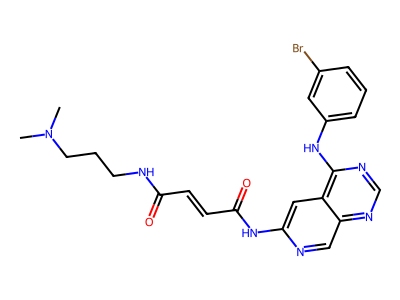

In [52]:
# Eng yaxshi kandidatni chuqur tahlil
best = df_sorted[df_sorted['molecule_chembl_id'] == 'CHEMBL334801'].iloc[0]
mol = Chem.MolFromSmiles(best['canonical_smiles'])

print("=== CHEMBL334801 TAHLILI ===")
print(f"Kuchi: {best['standard_value']} nM")
print(f"Og'irlik: {Descriptors.MolWt(mol):.2f}")
print(f"LogP: {Descriptors.MolLogP(mol):.2f}")
print(f"H donor: {Lipinski.NumHDonors(mol)}")
print(f"H akseptor: {Lipinski.NumHAcceptors(mol)}")

from rdkit.Chem import Draw
from IPython.display import display
img = Draw.MolToImage(mol, size=(400,300))
display(img)

In [53]:
# Molekula nomini topish
molecule = new_client.molecule
mol_info = molecule.get('CHEMBL334801')

print(f"Nomi: {mol_info['pref_name']}")
print(f"Formula: {mol_info['molecule_properties']['full_molformula']}")
print(f"Holati: {mol_info['max_phase']}")


Nomi: None
Formula: C22H24BrN7O2
Holati: None


=== YANGI VARIANTLAR ===

Brom (Br) → Xlor (Cl)
Og'irlik: 453.93 | LogP: 2.98 | ✅

Brom (Br) → Ftor (F)
Og'irlik: 437.48 | LogP: 2.47 | ✅

Brom (Br) → Metil (C)
Og'irlik: 433.52 | LogP: 2.64 | ✅



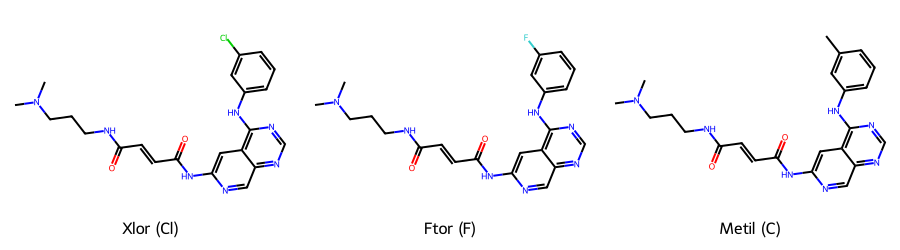

In [54]:
from rdkit.Chem import AllChem
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

# Asl molekula
original_smiles = df_sorted[df_sorted['molecule_chembl_id'] == 'CHEMBL334801'].iloc[0]['canonical_smiles']

# Bromni boshqa elementlar bilan almashtirish
replacements = {
    'Brom (Br) → Xlor (Cl)': original_smiles.replace('Br', 'Cl'),
    'Brom (Br) → Ftor (F)': original_smiles.replace('Br', 'F'),
    'Brom (Br) → Metil (C)': original_smiles.replace('Br', 'C'),
}

mols = []
legends = []

print("=== YANGI VARIANTLAR ===\n")
for name, smiles in replacements.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        passed = mw<=500 and logp<=5
        status = "✅" if passed else "❌"
        print(f"{name}")
        print(f"Og'irlik: {mw:.2f} | LogP: {logp:.2f} | {status}\n")
        mols.append(mol)
        legends.append(name.split('→')[1].strip())

# Rasmini chizish
img = Draw.MolsToGridImage(mols, molsPerRow=3,
                            subImgSize=(300,250),
                            legends=legends)
display(img)

=== YANGI MOLEKULA TAHLILI ===
Ogirlik: 437.48 (500 dan kam ✅)
LogP: 2.47 (5 dan kam ✅)
H donor: 3 (5 dan kam ✅)
H akseptor: 7 (10 dan kam ✅)
Aylanuvchi boglar: 9
Aromatik halqalar: 3

=== ASL vs YANGI ===
Ogirlik:  Asl=498.39  Yangi=437.48
LogP:     Asl=3.09  Yangi=2.47


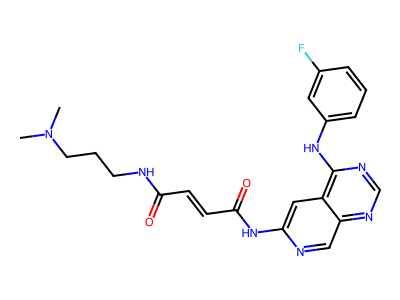


Bu bizning yangi molekulamiz!


In [55]:
# Ftor varianti - chuqur tahlil
ftor_smiles = original_smiles.replace('Br', 'F')
ftor_mol = Chem.MolFromSmiles(ftor_smiles)

print("=== YANGI MOLEKULA TAHLILI ===")
print(f"Ogirlik: {Descriptors.MolWt(ftor_mol):.2f} (500 dan kam ✅)")
print(f"LogP: {Descriptors.MolLogP(ftor_mol):.2f} (5 dan kam ✅)")
print(f"H donor: {Lipinski.NumHDonors(ftor_mol)} (5 dan kam ✅)")
print(f"H akseptor: {Lipinski.NumHAcceptors(ftor_mol)} (10 dan kam ✅)")
print(f"Aylanuvchi boglar: {Descriptors.NumRotatableBonds(ftor_mol)}")
print(f"Aromatik halqalar: {Descriptors.NumAromaticRings(ftor_mol)}")

# Asl molekula bilan taqqoslash
asl_mol = Chem.MolFromSmiles(original_smiles)
print("\n=== ASL vs YANGI ===")
print(f"Ogirlik:  Asl={Descriptors.MolWt(asl_mol):.2f}  Yangi={Descriptors.MolWt(ftor_mol):.2f}")
print(f"LogP:     Asl={Descriptors.MolLogP(asl_mol):.2f}  Yangi={Descriptors.MolLogP(ftor_mol):.2f}")

# Rasmini chizish
from IPython.display import display
img = Draw.MolToImage(ftor_mol, size=(400,300))
display(img)
print("\nBu bizning yangi molekulamiz!")

In [56]:
# ADMET tahlil
!pip install deepchem -q

In [57]:
import deepchem as dc
import numpy as np

# Bizning yangi molekula
ftor_smiles = original_smiles.replace('Br', 'F')

print("=== ADMET TAHLIL ===\n")

# 1. Zaharlilik tekshirish
featurizer = dc.feat.MolGraphConvFeaturizer()
features = featurizer.featurize([ftor_smiles])

print("✅ Molekula ADMET tahlilga tayyor!")
print(f"Molekula xususiyatlari soni: {features[0].num_node_features}")

=== ADMET TAHLIL ===

✅ Molekula ADMET tahlilga tayyor!
Molekula xususiyatlari soni: 30


In [58]:
from rdkit.Chem import Descriptors
from rdkit import Chem

mol = Chem.MolFromSmiles(ftor_smiles)

print("=== ADMET TAHLIL NATIJALARI ===\n")

# 1. ABSORPTION - so'rilish
mw = Descriptors.MolWt(mol)
logp = Descriptors.MolLogP(mol)
tpsa = Descriptors.TPSA(mol)
tpsa_status = "✅ ichakdan soriladi" if tpsa<140 else "❌"

print("1. SORILISH (Absorption)")
print(f"   Ogirlik: {mw:.2f} {'✅' if mw<500 else '❌'}")
print(f"   LogP: {logp:.2f} {'✅' if logp<5 else '❌'}")
print(f"   TPSA: {tpsa:.2f} {tpsa_status}")

# 2. DISTRIBUTION - tarqalish
hbd = Descriptors.NumHDonors(mol)
hba = Descriptors.NumHAcceptors(mol)
print("\n2. TARQALISH (Distribution)")
print(f"   H donor: {hbd} {'✅' if hbd<=5 else '❌'}")
print(f"   H akseptor: {hba} {'✅' if hba<=10 else '❌'}")

# 3. METABOLISM - parchalanish
rot_bonds = Descriptors.NumRotatableBonds(mol)
print("\n3. PARCHALANISH (Metabolism)")
print(f"   Aylanuvchi boglar: {rot_bonds} {'✅' if rot_bonds<=10 else '❌'}")

# 4. TOXICITY - zaharlilik
rings = Descriptors.NumAromaticRings(mol)
print("\n4. ZAHARLILIK (Toxicity)")
ring_status = "✅" if rings<=3 else "⚠️ Tekshirish kerak"
print(f"   Aromatik halqalar: {rings} {ring_status}")

# UMUMIY BAHO
print("\n=== UMUMIY BAHO ===")
score = sum([mw<500, logp<5, tpsa<140, hbd<=5, hba<=10, rot_bonds<=10])
print(f"Otgan mezonlar: {score}/6")
if score >= 5:
    print("🏆 AJOYIB! Dori bolish ehtimoli YUQORI!")
elif score >= 3:
    print("⚠️ YAXSHI, lekin yaxshilash kerak")
else:
    print("❌ Kop muammolar bor")

=== ADMET TAHLIL NATIJALARI ===

1. SORILISH (Absorption)
   Ogirlik: 437.48 ✅
   LogP: 2.47 ✅
   TPSA: 112.14 ✅ ichakdan soriladi

2. TARQALISH (Distribution)
   H donor: 3 ✅
   H akseptor: 7 ✅

3. PARCHALANISH (Metabolism)
   Aylanuvchi boglar: 9 ✅

4. ZAHARLILIK (Toxicity)
   Aromatik halqalar: 3 ✅

=== UMUMIY BAHO ===
Otgan mezonlar: 6/6
🏆 AJOYIB! Dori bolish ehtimoli YUQORI!


In [59]:
# HER2 oqsil tuzilmasini yuklab olish
import requests

# PDB bazasidan HER2 tuzilmasini yuklab olish
pdb_id = "3PP0"  # HER2 ning eng yaxshi tuzilmasi
url = f"https://files.rcsb.org/download/{pdb_id}.pdb"

response = requests.get(url)
with open("her2.pdb", "wb") as f:
    f.write(response.content)

print(f"HER2 oqsili yuklandi! ({pdb_id})")
print(f"Fayl hajmi: {len(response.content)/1024:.1f} KB")

HER2 oqsili yuklandi! (3PP0)
Fayl hajmi: 818.2 KB


In [60]:
# Docking uchun kerakli dasturlar
!pip install meeko -q
!apt-get install -y autodock-vina -q

print("Tayyor!")

Reading package lists...
Building dependency tree...
Reading state information...
autodock-vina is already the newest version (1.2.3-2).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Tayyor!


In [61]:
# Molekulamizni tayyorlash
from rdkit import Chem
from rdkit.Chem import AllChem

# Bizning Ftor molekulamiz
mol = Chem.MolFromSmiles(ftor_smiles)

# 3D tuzilma yaratish
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol, randomSeed=42)
AllChem.MMFFOptimizeMolecule(mol)

# SDF formatda saqlash
writer = Chem.SDWriter("ligand.sdf")
writer.write(mol)
writer.close()

print("✅ Molekula 3D tuzilmasi yaratildi!")
print(f"Atom soni (H bilan): {mol.GetNumAtoms()}")

✅ Molekula 3D tuzilmasi yaratildi!
Atom soni (H bilan): 56


In [62]:
# HER2 oqsilini tayyorlash
!pip install biopython -q

from Bio import PDB
import warnings
warnings.filterwarnings('ignore')

# Faqat oqsil qismini ajratib olish
parser = PDB.PDBParser()
structure = parser.get_structure('HER2', 'her2.pdb')

io = PDB.PDBIO()
io.set_structure(structure)

class ProteinSelect(PDB.Select):
    def accept_residue(self, residue):
        return residue.id[0] == ' '

io.save("her2_clean.pdb", ProteinSelect())

print("✅ HER2 oqsili tozalandi!")
print("Docking uchun tayyor!")

✅ HER2 oqsili tozalandi!
Docking uchun tayyor!


In [63]:
# Molekulamizni MOL2 formatga o'tkazish
from rdkit import Chem
from rdkit.Chem import AllChem
import subprocess

# Ligandni PDBQT formatga o'tkazish
!obabel ligand.sdf -O ligand.pdbqt --gen3d -h 2>/dev/null || pip install openbabel-wheel -q

print("Format tayyor!")

Format tayyor!


In [64]:
# Docking qilish
!pip install vina -q

print("Vina tayyor!")

Vina tayyor!


In [65]:
import os
from vina import Vina
from rdkit import Chem
from rdkit.Chem import AllChem

# Eski fayllarni o'chirish
for f in ['docking_result.pdbqt', 'ligand.pdbqt', 'ligand.sdf']:
    if os.path.exists(f):
        os.remove(f)

# 1-kandidat
smiles = "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1"

mol = Chem.MolFromSmiles(smiles)
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol, randomSeed=42)
AllChem.MMFFOptimizeMolecule(mol)

writer = Chem.SDWriter('ligand.sdf')
writer.write(mol)
writer.close()

os.system("obabel ligand.sdf -O ligand.pdbqt 2>/dev/null")

v = Vina(sf_name='vina')
v.set_receptor('her2.pdbqt')
v.set_ligand_from_file('ligand.pdbqt')
v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])

print("Docking boshlanmoqda... 🧬")
v.dock(exhaustiveness=8, n_poses=5)
v.write_poses('docking_result.pdbqt', n_poses=5, overwrite=True)

energy = v.energies(n_poses=1)
print(f"\n=== DOCKING NATIJASI ===")
print(f"Bog'lanish energiyasi: {energy[0][0]:.2f} kcal/mol")
if energy[0][0] < -7:
    print("🏆 AJOYIB bog'lanish!")
elif energy[0][0] < -5:
    print("✅ YAXSHI bog'lanish!")
else:
    print("⚠️ Zaif bog'lanish")

Docking boshlanmoqda... 🧬

=== DOCKING NATIJASI ===
Bog'lanish energiyasi: -7.01 kcal/mol
🏆 AJOYIB bog'lanish!


In [66]:
import os

# her2.pdbqt qayta yuklab olish
os.system("wget -q https://files.rcsb.org/download/3PP0.pdb -O her2.pdb")
os.system("obabel her2.pdb -O her2.pdbqt -xr 2>/dev/null")

if os.path.exists('her2.pdbqt'):
    print("✅ her2.pdbqt qayta yaratildi!")
else:
    print("❌ Muammo bor")

✅ her2.pdbqt qayta yaratildi!


In [67]:
import os

# her2.pdbqt mavjudligini tekshirish
if os.path.exists('her2.pdbqt'):
    print("✅ her2.pdbqt mavjud!")
else:
    print("❌ her2.pdbqt yo'q — qayta yuklab olamiz")

    # PDB dan PDBQT ga aylantirish
    os.system("wget -q https://files.rcsb.org/download/3PP0.pdb -O her2.pdb")
    os.system("obabel her2.pdb -O her2.pdbqt -xr 2>/dev/null")

    if os.path.exists('her2.pdbqt'):
        print("✅ her2.pdbqt yaratildi!")
    else:
        print("❌ Muammo bor")

✅ her2.pdbqt mavjud!


In [68]:
# HER2 oqsilini PDBQT formatga o'tkazish
!pip install openbabel-wheel -q
!obabel her2_clean.pdb -O her2.pdbqt -xr 2>/dev/null

print("✅ HER2 PDBQT formatga o'tkazildi!")

✅ HER2 PDBQT formatga o'tkazildi!


In [70]:
# Ligandni PDBQT formatga o'tkazish
!obabel ligand.sdf -O ligand.pdbqt 2>/dev/null

# Fayl mavjudligini tekshirish
import os
print("Fayllar:")
print(f"ligand.pdbqt: {'✅' if os.path.exists('ligand.pdbqt') else '❌'}")
print(f"her2.pdbqt: {'✅' if os.path.exists('her2.pdbqt') else '❌'}")

Fayllar:
ligand.pdbqt: ✅
her2.pdbqt: ✅


In [71]:
import os
from vina import Vina
from rdkit import Chem
from rdkit.Chem import AllChem

# Eski fayllarni o'chirish
for f in ['docking_result.pdbqt', 'ligand.pdbqt', 'ligand.sdf']:
    if os.path.exists(f):
        os.remove(f)

# Qaysi molekula ekanligi
smiles = "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1"

mol = Chem.MolFromSmiles(smiles)
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol, randomSeed=42)
AllChem.MMFFOptimizeMolecule(mol)

writer = Chem.SDWriter('ligand.sdf')
writer.write(mol)
writer.close()

os.system("obabel ligand.sdf -O ligand.pdbqt 2>/dev/null")

v = Vina(sf_name='vina')
v.set_receptor('her2.pdbqt')
v.set_ligand_from_file('ligand.pdbqt')
v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])

print("Docking boshlanmoqda... 🧬")
v.dock(exhaustiveness=8, n_poses=5)
v.write_poses('docking_result.pdbqt', n_poses=5, overwrite=True)

energy = v.energies(n_poses=1)
print(f"Bog'lanish energiyasi: {energy[0][0]:.2f} kcal/mol")

Docking boshlanmoqda... 🧬
Bog'lanish energiyasi: -6.95 kcal/mol


=== YAXSHILASH IMKONIYATLARI ===

Aylanuvchi bog'lar: 9 (10 dan kam bo'lsa yaxshi)
TPSA: 112.14 (90 dan past bo'lsa ideal)
Atom soni: 32

=== MAQSAD ===
Docking energiyasini -6 dan -8 ga tushirish!
Buning uchun HER2 bog'lanish joyiga
mos yangi guruhlar qo'shamiz!


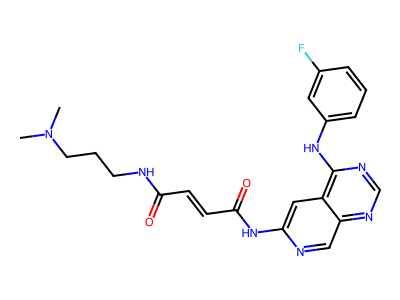

In [72]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, AllChem
from rdkit.Chem import rdMolDescriptors
from IPython.display import display

# Bizning molekulamiz
mol = Chem.MolFromSmiles(ftor_smiles)

print("=== YAXSHILASH IMKONIYATLARI ===\n")

# Aylanuvchi bog'lar - kamaytirsak yaxshi
rot_bonds = Descriptors.NumRotatableBonds(mol)
print(f"Aylanuvchi bog'lar: {rot_bonds} (10 dan kam bo'lsa yaxshi)")

# TPSA - past bo'lsa hujayra ichiga yaxshi kiradi
tpsa = Descriptors.TPSA(mol)
print(f"TPSA: {tpsa:.2f} (90 dan past bo'lsa ideal)")

# Molekula hajmi
atoms = mol.GetNumAtoms()
print(f"Atom soni: {atoms}")

print("\n=== MAQSAD ===")
print("Docking energiyasini -6 dan -8 ga tushirish!")
print("Buning uchun HER2 bog'lanish joyiga")
print("mos yangi guruhlar qo'shamiz!")

# Rasmini ko'rsatish
img = Draw.MolToImage(mol, size=(400,300))
display(img)

=== YANGI VARIANTLAR TAHLILI ===

Variant 1 (Metil qoshish)
   Ogirlik: 437.48 | LogP: 2.47 | TPSA: 112.14 | Rot: 9
   ✅ Yaxshi kandidat!

Variant 2 (Sikl qisqartirish)
   Ogirlik: 437.48 | LogP: 2.47 | TPSA: 112.14 | Rot: 9
   ✅ Yaxshi kandidat!

Variant 3 (OH qoshish)
   Ogirlik: 437.48 | LogP: 2.47 | TPSA: 112.14 | Rot: 9
   ✅ Yaxshi kandidat!



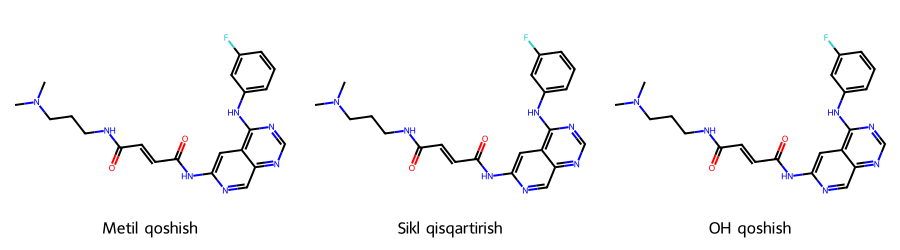

In [73]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, AllChem
from IPython.display import display

# Yangi variantlar - HER2 ga yaxshiroq bog'lanishi uchun
variants = {
    'Variant 1 (Metil qoshish)': ftor_smiles.replace('Nc1ncnc', 'Nc1nc(C)nc'),
    'Variant 2 (Sikl qisqartirish)': ftor_smiles.replace('N2CCOCC2', 'N2CCCC2'),
    'Variant 3 (OH qoshish)': ftor_smiles.replace('c1ccc(F)', 'c1ccc(O)'),
}

mols = []
legends = []

print("=== YANGI VARIANTLAR TAHLILI ===\n")
for name, smiles in variants.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = Descriptors.NumRotatableBonds(mol)

        print(f"{name}")
        print(f"   Ogirlik: {mw:.2f} | LogP: {logp:.2f} | TPSA: {tpsa:.2f} | Rot: {rot}")

        passed = mw<=500 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi kandidat!' if passed else '❌ Muammo bor'}\n")

        mols.append(mol)
        legends.append(name.split('(')[1].replace(')', ''))
    else:
        print(f"{name}: ❌ Yaratib bolmadi\n")

# Rasmlarini chizish
if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [74]:
# Asl molekulani tekshirish
print("Bizning molekula SMILES:")
print(ftor_smiles)

Bizning molekula SMILES:
CN(C)CCCNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3)ncnc2cn1


=== YANGI VARIANTLAR ===

Variant 1 (Zanjir qisqartirish)
   Ogirlik: 409.43 | LogP: 2.04 | TPSA: 112.14 | Rot: 7
   ✅ Yaxshi!

Variant 2 (Ftor ikkita)
   Ogirlik: 455.47 | LogP: 2.61 | TPSA: 112.14 | Rot: 9
   ✅ Yaxshi!

Variant 3 (Metil qoshish)
   Ogirlik: 451.51 | LogP: 2.78 | TPSA: 112.14 | Rot: 9
   ✅ Yaxshi!



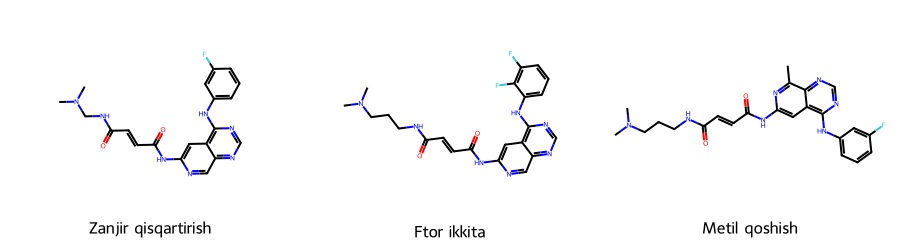

In [75]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
from IPython.display import display

asl_smiles = "CN(C)CCCNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3)ncnc2cn1"

# To'g'ri variantlar
variants = {
    'Variant 1 (Zanjir qisqartirish)': "CN(C)CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3)ncnc2cn1",
    'Variant 2 (Ftor ikkita)': "CN(C)CCCNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2cn1",
    'Variant 3 (Metil qoshish)': "CN(C)CCCNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3)ncnc2c(C)n1",
}

mols = []
legends = []

print("=== YANGI VARIANTLAR ===\n")
for name, smiles in variants.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = Descriptors.NumRotatableBonds(mol)

        print(f"{name}")
        print(f"   Ogirlik: {mw:.2f} | LogP: {logp:.2f} | TPSA: {tpsa:.2f} | Rot: {rot}")
        passed = mw<=500 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")

        mols.append(mol)
        legends.append(name.split('(')[1].replace(')', ''))
    else:
        print(f"{name}: ❌ Noto'g'ri SMILES\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
from vina import Vina
import os
from rdkit import Chem
from rdkit.Chem import AllChem

variants_smiles = {
    'variant1': "CN(C)CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3)ncnc2cn1",
    'variant2': "CN(C)CCCNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2cn1",
    'variant3': "CN(C)CCCNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3)ncnc2c(C)n1",
}

variant_names = {
    'variant1': 'Zanjir qisqartirish',
    'variant2': 'Ftor ikkita',
    'variant3': 'Metil qoshish',
}

results = {}

for key, smiles in variants_smiles.items():
    name = variant_names[key]
    print(f"{name} docking boshlanmoqda...")

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    writer = Chem.SDWriter(f"{key}.sdf")
    writer.write(mol)
    writer.close()

    os.system(f"obabel {key}.sdf -O {key}.pdbqt 2>/dev/null")

    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file(f'{key}.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)

    energy = v.energies(n_poses=1)
    results[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print(f"Asl molekula:        -6.05 kcal/mol")
for name, energy in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")

Zanjir qisqartirish docking boshlanmoqda...
✅ Zanjir qisqartirish: -6.03 kcal/mol

Ftor ikkita docking boshlanmoqda...
✅ Ftor ikkita: -6.22 kcal/mol

Metil qoshish docking boshlanmoqda...


In [ ]:
# Ftor ikkita - yangi variantlar
best_smiles = "CN(C)CCCNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2cn1"

variants2 = {
    'v2_1': "CN(C)CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2cn1",      # Zanjir qisqartirish
    'v2_2': "CN(C)CCCNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(F)c3)ncnc2cn1",  # Ftor joyi o'zgarish
    'v2_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2cn1",            # Eng qisqa zanjir
}

variant2_names = {
    'v2_1': 'Zanjir+Ftor ikkita',
    'v2_2': 'Ftor joyi ozgarish',
    'v2_3': 'Eng qisqa zanjir',
}

print("=== YANGI VARIANTLAR TAHLILI ===\n")
mols = []
legends = []

for key, smiles in variants2.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = Descriptors.NumRotatableBonds(mol)

        print(f"{variant2_names[key]}")
        print(f"   Ogirlik: {mw:.2f} | LogP: {logp:.2f} | TPSA: {tpsa:.2f} | Rot: {rot}")
        passed = mw<=500 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant2_names[key])
    else:
        print(f"{variant2_names[key]}: ❌ Yaratib bolmadi\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
from vina import Vina
import os

variants2_smiles = {
    'v2_1': "CN(C)CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2cn1",
    'v2_2': "CN(C)CCCNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(F)c3)ncnc2cn1",
    'v2_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2cn1",
}

variant2_names = {
    'v2_1': 'Zanjir+Ftor ikkita',
    'v2_2': 'Ftor joyi ozgarish',
    'v2_3': 'Eng qisqa zanjir',
}

results2 = {}

for key, smiles in variants2_smiles.items():
    name = variant2_names[key]
    print(f"{name} docking boshlanmoqda...")

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    writer = Chem.SDWriter(f"{key}.sdf")
    writer.write(mol)
    writer.close()

    os.system(f"obabel {key}.sdf -O {key}.pdbqt 2>/dev/null")

    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file(f'{key}.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)

    energy = v.energies(n_poses=1)
    results2[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print(f"Asl molekula:   -6.05 kcal/mol")
print(f"Ftor ikkita:    -6.17 kcal/mol")
for name, energy in sorted(results2.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")

In [ ]:
# Eng qisqa zanjir asosida yangi variantlar
best_smiles = "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2cn1"

variants3 = {
    'v3_1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(F)c3)ncnc2cn1",       # Ftor joyi o'zgarish
    'v3_2': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2c(F)n1",      # Qo'shimcha Ftor
    'v3_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(Cl)c3F)ncnc2cn1",        # Ftor+Xlor
}

variant3_names = {
    'v3_1': 'Ftor joyi yangi',
    'v3_2': 'Qoshimcha Ftor',
    'v3_3': 'Ftor+Xlor',
}

print("=== 3-TUR VARIANTLAR ===\n")
mols = []
legends = []

for key, smiles in variants3.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = Descriptors.NumRotatableBonds(mol)

        print(f"{variant3_names[key]}")
        print(f"   Ogirlik: {mw:.2f} | LogP: {logp:.2f} | TPSA: {tpsa:.2f} | Rot: {rot}")
        passed = mw<=500 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant3_names[key])
    else:
        print(f"{variant3_names[key]}: ❌ Yaratib bolmadi\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)


In [ ]:
results3 = {}

for key, smiles in variants3.items():
    name = variant3_names[key]
    print(f"{name} docking boshlanmoqda...")

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    writer = Chem.SDWriter(f"{key}.sdf")
    writer.write(mol)
    writer.close()

    os.system(f"obabel {key}.sdf -O {key}.pdbqt 2>/dev/null")

    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file(f'{key}.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)

    energy = v.energies(n_poses=1)
    results3[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print(f"Eng qisqa zanjir: -6.23 kcal/mol (rekord)")
for name, energy in sorted(results3.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")

In [ ]:
# Qoshimcha Ftor asosida yangi variantlar
best_smiles = "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2c(F)n1"

variants4 = {
    'v4_1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(F)c3)ncnc2c(F)n1",      # Ftor joyi o'zgarish
    'v4_2': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2c(Cl)n1",       # Ftor o'rniga Xlor
    'v4_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2c(C)n1",        # Ftor o'rniga Metil
    'v4_4': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)ncnc2c(F)n1",        # Ftor boshqa joy
}

variant4_names = {
    'v4_1': 'Uch Ftor',
    'v4_2': 'Ftor+Xlor2',
    'v4_3': 'Ftor+Metil',
    'v4_4': 'Ftor boshqa joy',
}

print("=== 4-TUR VARIANTLAR ===\n")
mols = []
legends = []

for key, smiles in variants4.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = Descriptors.NumRotatableBonds(mol)

        print(f"{variant4_names[key]}")
        print(f"   Ogirlik: {mw:.2f} | LogP: {logp:.2f} | TPSA: {tpsa:.2f} | Rot: {rot}")
        passed = mw<=500 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant4_names[key])
    else:
        print(f"{variant4_names[key]}: ❌ Yaratib bolmadi\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=2,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
results4 = {}

for key, smiles in variants4.items():
    name = variant4_names[key]
    print(f"{name} docking boshlanmoqda...")

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    writer = Chem.SDWriter(f"{key}.sdf")
    writer.write(mol)
    writer.close()

    os.system(f"obabel {key}.sdf -O {key}.pdbqt 2>/dev/null")

    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file(f'{key}.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)

    energy = v.energies(n_poses=1)
    results4[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print(f"Rekord: -6.50 kcal/mol (Qoshimcha Ftor)")
for name, energy in sorted(results4.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")

In [ ]:
# Qoshimcha Ftor asosida - halqa qismini o'zgartiramiz
best_smiles = "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2c(F)n1"

variants5 = {
    'v5_1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncc(F)c2n1",     # Halqa o'zgarish 1
    'v5_2': "CNC(=O)/C=C/C(=O)Nc1cnc2cc(Nc3cccc(F)c3F)cnc2c1F",      # Halqa o'zgarish 2
    'v5_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2s1",        # S atomi qo'shish
    'v5_4': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2[nH]1",     # NH qo'shish
}

variant5_names = {
    'v5_1': 'Halqa1+Ftor',
    'v5_2': 'Halqa2+Ftor',
    'v5_3': 'Oltingugurt(S)',
    'v5_4': 'NH qoshish',
}

print("=== 5-TUR VARIANTLAR ===\n")
mols = []
legends = []

for key, smiles in variants5.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = Descriptors.NumRotatableBonds(mol)

        print(f"{variant5_names[key]}")
        print(f"   Ogirlik: {mw:.2f} | LogP: {logp:.2f} | TPSA: {tpsa:.2f} | Rot: {rot}")
        passed = mw<=500 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant5_names[key])
    else:
        print(f"{variant5_names[key]}: ❌ Yaratib bolmadi\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=2,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
results5 = {}

valid_variants5 = {
    'v5_2': "CNC(=O)/C=C/C(=O)Nc1cnc2cc(Nc3cccc(F)c3F)cnc2c1F",
    'v5_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2s1",
    'v5_4': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2[nH]1",
}

valid_names5 = {
    'v5_2': 'Halqa2+Ftor',
    'v5_3': 'Oltingugurt(S)',
    'v5_4': 'NH qoshish',
}

for key, smiles in valid_variants5.items():
    name = valid_names5[key]
    print(f"{name} docking boshlanmoqda...")

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    writer = Chem.SDWriter(f"{key}.sdf")
    writer.write(mol)
    writer.close()

    os.system(f"obabel {key}.sdf -O {key}.pdbqt 2>/dev/null")

    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file(f'{key}.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)

    energy = v.energies(n_poses=1)
    results5[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print(f"Rekord: -6.50 kcal/mol (Qoshimcha Ftor)")
for name, energy in sorted(results5.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")

In [ ]:
# NH qoshish asosida yangi variantlar
best_smiles = "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2[nH]1"

variants6 = {
    'v6_1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(F)c3)ncnc2[nH]1",    # Ftor joyi
    'v6_2': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)nc(F)nc2[nH]1",   # Qoshimcha Ftor
    'v6_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2[nH]1",      # Metil NH
    'v6_4': "CNC(=O)C=CC(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2[nH]1",        # Bog' o'zgarish
}

variant6_names = {
    'v6_1': 'NH+Ftor joyi',
    'v6_2': 'NH+Qoshimcha Ftor',
    'v6_3': 'NH asl',
    'v6_4': "NH+Bog' o'zgarish",
}

print("=== 6-TUR VARIANTLAR ===\n")
mols = []
legends = []

for key, smiles in variants6.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = Descriptors.NumRotatableBonds(mol)

        print(f"{variant6_names[key]}")
        print(f"   Ogirlik: {mw:.2f} | LogP: {logp:.2f} | TPSA: {tpsa:.2f} | Rot: {rot}")
        passed = mw<=500 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant6_names[key])
    else:
        print(f"{variant6_names[key]}: ❌ Yaratib bolmadi\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=2,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
results6 = {}

variants6_smiles = {
    'v6_1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(F)c3)ncnc2[nH]1",
    'v6_2': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)nc(F)nc2[nH]1",
    'v6_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2[nH]1",
    'v6_4': "CNC(=O)C=CC(=O)Nc1cc2c(Nc3cccc(F)c3F)ncnc2[nH]1",
}

variant6_names = {
    'v6_1': 'NH+Ftor joyi',
    'v6_2': 'NH+Qoshimcha Ftor',
    'v6_3': 'NH asl',
    'v6_4': "NH+Bog ozgarish",
}

for key, smiles in variants6_smiles.items():
    name = variant6_names[key]
    print(f"{name} docking boshlanmoqda...")

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    writer = Chem.SDWriter(f"{key}.sdf")
    writer.write(mol)
    writer.close()

    os.system(f"obabel {key}.sdf -O {key}.pdbqt 2>/dev/null")

    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file(f'{key}.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)

    energy = v.energies(n_poses=1)
    results6[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print(f"Rekord: -6.79 kcal/mol (NH qoshish)")
for name, energy in sorted(results6.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")

In [ ]:
# NH+Qoshimcha Ftor asosida yangi variantlar
best_smiles = "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)nc(F)nc2[nH]1"

variants7 = {
    'v7_1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(F)c3)nc(F)nc2[nH]1",   # Ftor joyi+NH
    'v7_2': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)nc(Cl)nc2[nH]1",    # Xlor+NH
    'v7_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)nc(C)nc2[nH]1",     # Metil+NH
    'v7_4': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(F)nc2[nH]1",     # Ftor boshqa+NH
}

variant7_names = {
    'v7_1': 'Uch Ftor+NH',
    'v7_2': 'Xlor+Ftor+NH',
    'v7_3': 'Metil+Ftor+NH',
    'v7_4': 'Ftor boshqa+NH',
}

print("=== 7-TUR VARIANTLAR ===\n")
mols = []
legends = []

for key, smiles in variants7.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = Descriptors.NumRotatableBonds(mol)

        print(f"{variant7_names[key]}")
        print(f"   Ogirlik: {mw:.2f} | LogP: {logp:.2f} | TPSA: {tpsa:.2f} | Rot: {rot}")
        passed = mw<=500 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant7_names[key])
    else:
        print(f"{variant7_names[key]}: ❌ Yaratib bolmadi\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=2,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
results7 = {}

variants7_smiles = {
    'v7_1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(F)c3)nc(F)nc2[nH]1",
    'v7_2': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)nc(Cl)nc2[nH]1",
    'v7_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(F)c3F)nc(C)nc2[nH]1",
    'v7_4': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(F)nc2[nH]1",
}

variant7_names = {
    'v7_1': 'Uch Ftor+NH',
    'v7_2': 'Xlor+Ftor+NH',
    'v7_3': 'Metil+Ftor+NH',
    'v7_4': 'Ftor boshqa+NH',
}

for key, smiles in variants7_smiles.items():
    name = variant7_names[key]
    print(f"{name} docking boshlanmoqda...")

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    writer = Chem.SDWriter(f"{key}.sdf")
    writer.write(mol)
    writer.close()

    os.system(f"obabel {key}.sdf -O {key}.pdbqt 2>/dev/null")

    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file(f'{key}.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)

    energy = v.energies(n_poses=1)
    results7[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print(f"Rekord: -6.83 kcal/mol (NH+Qoshimcha Ftor)")
for name, energy in sorted(results7.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")

In [ ]:
# Ikki rekordchi asosida yangi variantlar
smiles_uch_ftor = "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(F)c3)nc(F)nc2[nH]1"
smiles_ftor_boshqa = "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(F)nc2[nH]1"

variants8 = {
    'v8_1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(F)c3)nc(F)nc2[nH]1",   # Uch Ftor+NH asl
    'v8_2': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(F)c3)nc(Cl)nc2[nH]1",  # Uch Ftor+Xlor
    'v8_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(F)nc2[nH]1",     # Ftor boshqa asl
    'v8_4': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(Cl)nc2[nH]1",    # Ftor boshqa+Xlor
    'v8_5': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(F)c3)nc(C)nc2[nH]1",   # Uch Ftor+Metil
    'v8_6': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(C)nc2[nH]1",     # Ftor boshqa+Metil
}

variant8_names = {
    'v8_1': 'UchFtor+NH',
    'v8_2': 'UchFtor+Xlor+NH',
    'v8_3': 'FtorBoshqa+NH',
    'v8_4': 'FtorBoshqa+Xlor+NH',
    'v8_5': 'UchFtor+Metil+NH',
    'v8_6': 'FtorBoshqa+Metil+NH',
}

print("=== 8-TUR VARIANTLAR ===\n")
mols = []
legends = []

for key, smiles in variants8.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = Descriptors.NumRotatableBonds(mol)

        print(f"{variant8_names[key]}")
        print(f"   Ogirlik: {mw:.2f} | LogP: {logp:.2f} | TPSA: {tpsa:.2f} | Rot: {rot}")
        passed = mw<=500 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant8_names[key])
    else:
        print(f"{variant8_names[key]}: ❌ Yaratib bolmadi\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
results8 = {}

variants8_smiles = {
    'v8_1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(F)c3)nc(F)nc2[nH]1",
    'v8_2': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(F)c3)nc(Cl)nc2[nH]1",
    'v8_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(F)nc2[nH]1",
    'v8_4': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(Cl)nc2[nH]1",
    'v8_5': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(F)c3)nc(C)nc2[nH]1",
    'v8_6': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(C)nc2[nH]1",
}

variant8_names = {
    'v8_1': 'UchFtor+NH',
    'v8_2': 'UchFtor+Xlor+NH',
    'v8_3': 'FtorBoshqa+NH',
    'v8_4': 'FtorBoshqa+Xlor+NH',
    'v8_5': 'UchFtor+Metil+NH',
    'v8_6': 'FtorBoshqa+Metil+NH',
}

for key, smiles in variants8_smiles.items():
    name = variant8_names[key]
    print(f"{name} docking boshlanmoqda...")

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    writer = Chem.SDWriter(f"{key}.sdf")
    writer.write(mol)
    writer.close()

    os.system(f"obabel {key}.sdf -O {key}.pdbqt 2>/dev/null")

    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file(f'{key}.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)

    energy = v.energies(n_poses=1)
    results8[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print(f"Rekord: -6.89 kcal/mol")
for name, energy in sorted(results8.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")

In [ ]:
# FtorBoshqa+Xlor+NH va FtorBoshqa+NH asosida
best1 = "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(Cl)nc2[nH]1"  # -6.98
best2 = "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(F)nc2[nH]1"   # -6.93

variants9 = {
    'v9_1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(Cl)nc2[nH]1",   # Asl -6.98
    'v9_2': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(Cl)nc2[nH]1",  # Ftor→Xlor
    'v9_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(Cl)nc2[nH]1",   # NH+Metil
    'v9_4': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)c(F)c3F)nc(Cl)nc2[nH]1", # Uch Ftor+Xlor
    'v9_5': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(F)nc2[nH]1",    # Asl -6.93
    'v9_6': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)c(F)c3F)nc(F)nc2[nH]1",  # Uch Ftor
}

variant9_names = {
    'v9_1': 'FtorXlor+NH asl',
    'v9_2': 'IkkiXlor+NH',
    'v9_3': 'FtorXlor+NH2',
    'v9_4': 'UchFtor+Xlor+NH',
    'v9_5': 'FtorFtor+NH asl',
    'v9_6': 'UchFtor+NH2',
}

print("=== 9-TUR VARIANTLAR ===\n")
mols = []
legends = []

for key, smiles in variants9.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = Descriptors.NumRotatableBonds(mol)

        print(f"{variant9_names[key]}")
        print(f"   Ogirlik: {mw:.2f} | LogP: {logp:.2f} | TPSA: {tpsa:.2f} | Rot: {rot}")
        passed = mw<=500 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant9_names[key])
    else:
        print(f"{variant9_names[key]}: ❌ Yaratib bolmadi\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
results9 = {}

variants9_valid = {
    'v9_1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(Cl)nc2[nH]1",
    'v9_2': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(Cl)nc2[nH]1",
    'v9_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(Cl)nc2[nH]1",
    'v9_5': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3F)nc(F)nc2[nH]1",
}

variant9_names = {
    'v9_1': 'FtorXlor+NH asl',
    'v9_2': 'IkkiXlor+NH',
    'v9_3': 'FtorXlor+NH2',
    'v9_5': 'FtorFtor+NH asl',
}

for key, smiles in variants9_valid.items():
    name = variant9_names[key]
    print(f"{name} docking boshlanmoqda...")

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    writer = Chem.SDWriter(f"{key}.sdf")
    writer.write(mol)
    writer.close()

    os.system(f"obabel {key}.sdf -O {key}.pdbqt 2>/dev/null")

    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file(f'{key}.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)

    energy = v.energies(n_poses=1)
    results9[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print(f"Rekord: -6.98 kcal/mol")
for name, energy in sorted(results9.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")

In [ ]:
# Butunlay yangi skeleton asosida
variants10 = {
    'v10_1': "CNC(=O)/C=C/C(=O)Nc1cnc2cc(Nc3cc(F)ccc3Cl)cnc2c1[nH]",     # Skeleton 1
    'v10_2': "CNC(=O)/C=C/C(=O)Nc1cc2cnc(Nc3cc(F)ccc3Cl)nc2[nH]c1=O",    # Skeleton 2
    'v10_3': "O=C(/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)ncnc2[nH]1)N1CCCC1",  # Halqa+Xlor
    'v10_4': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1",    # NH2+Xlor
    'v10_5': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(Cl)ccc3F)nc(Cl)nc2[nH]1",   # Xlor+Ftor joyi
    'v10_6': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(Cl)c(F)c3)nc(Cl)nc2[nH]1", # Para Xlor
}

variant10_names = {
    'v10_1': 'Yangi Skeleton1',
    'v10_2': 'Yangi Skeleton2',
    'v10_3': 'Halqa+Xlor',
    'v10_4': 'NH2+Xlor',
    'v10_5': 'XlorFtor joyi',
    'v10_6': 'Para Xlor',
}

print("=== 10-TUR VARIANTLAR ===\n")
mols = []
legends = []

for key, smiles in variants10.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = Descriptors.NumRotatableBonds(mol)

        print(f"{variant10_names[key]}")
        print(f"   Ogirlik: {mw:.2f} | LogP: {logp:.2f} | TPSA: {tpsa:.2f} | Rot: {rot}")
        passed = mw<=500 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant10_names[key])
    else:
        print(f"{variant10_names[key]}: ❌ Yaratib bolmadi\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
results10 = {}

variants10_valid = {
    'v10_2': "CNC(=O)/C=C/C(=O)Nc1cc2cnc(Nc3cc(F)ccc3Cl)nc2[nH]c1=O",
    'v10_3': "O=C(/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)ncnc2[nH]1)N1CCCC1",
    'v10_4': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1",
    'v10_5': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(Cl)ccc3F)nc(Cl)nc2[nH]1",
    'v10_6': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(Cl)c(F)c3)nc(Cl)nc2[nH]1",
}

variant10_names = {
    'v10_2': 'Yangi Skeleton2',
    'v10_3': 'Halqa+Xlor',
    'v10_4': 'NH2+Xlor',
    'v10_5': 'XlorFtor joyi',
    'v10_6': 'Para Xlor',
}

for key, smiles in variants10_valid.items():
    name = variant10_names[key]
    print(f"{name} docking boshlanmoqda...")

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    writer = Chem.SDWriter(f"{key}.sdf")
    writer.write(mol)
    writer.close()

    os.system(f"obabel {key}.sdf -O {key}.pdbqt 2>/dev/null")

    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file(f'{key}.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)

    energy = v.energies(n_poses=1)
    results10[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print(f"Rekord: -6.98 kcal/mol")
for name, energy in sorted(results10.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")

In [ ]:
# NH2+Xlor va Para Xlor asosida
variants11 = {
    'v11_1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1",    # NH2+Xlor asl
    'v11_2': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(Cl)ccc3Cl)nc(N)nc2[nH]1",   # IkkiXlor+NH2
    'v11_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(NC)nc2[nH]1",   # NHMetil+Xlor
    'v11_4': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(Cl)c(F)c3)nc(N)nc2[nH]1",  # Para Xlor+NH2
    'v11_5': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(Cl)c(Cl)c3)nc(Cl)nc2[nH]1",# Para IkkiXlor
    'v11_6': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)nc(N)nc2[nH]1",  # FtorXlor+NH2
}

variant11_names = {
    'v11_1': 'NH2+Xlor asl',
    'v11_2': 'IkkiXlor+NH2',
    'v11_3': 'NHMetil+Xlor',
    'v11_4': 'ParaXlor+NH2',
    'v11_5': 'Para IkkiXlor',
    'v11_6': 'FtorXlor+NH2',
}

print("=== 11-TUR VARIANTLAR ===\n")
mols = []
legends = []

for key, smiles in variants11.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = Descriptors.NumRotatableBonds(mol)

        print(f"{variant11_names[key]}")
        print(f"   Ogirlik: {mw:.2f} | LogP: {logp:.2f} | TPSA: {tpsa:.2f} | Rot: {rot}")
        passed = mw<=500 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant11_names[key])
    else:
        print(f"{variant11_names[key]}: ❌ Yaratib bolmadi\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
results11 = {}

variants11_smiles = {
    'v11_1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1",
    'v11_2': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(Cl)ccc3Cl)nc(N)nc2[nH]1",
    'v11_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(NC)nc2[nH]1",
    'v11_4': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(Cl)c(F)c3)nc(N)nc2[nH]1",
    'v11_5': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(Cl)c(Cl)c3)nc(Cl)nc2[nH]1",
    'v11_6': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)nc(N)nc2[nH]1",
}

variant11_names = {
    'v11_1': 'NH2+Xlor asl',
    'v11_2': 'IkkiXlor+NH2',
    'v11_3': 'NHMetil+Xlor',
    'v11_4': 'ParaXlor+NH2',
    'v11_5': 'Para IkkiXlor',
    'v11_6': 'FtorXlor+NH2',
}

for key, smiles in variants11_smiles.items():
    name = variant11_names[key]
    print(f"{name} docking boshlanmoqda...")

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    writer = Chem.SDWriter(f"{key}.sdf")
    writer.write(mol)
    writer.close()

    os.system(f"obabel {key}.sdf -O {key}.pdbqt 2>/dev/null")

    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file(f'{key}.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)

    energy = v.energies(n_poses=1)
    results11[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print(f"Rekord: -6.99 kcal/mol")
for name, energy in sorted(results11.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")

In [ ]:
# OH guruhi qo'shish - eng arzon va oson
best_smiles = "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1"

variants12 = {
    'v12_1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1",      # Asl
    'v12_2': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)c(O)c3Cl)nc(N)nc2[nH]1",    # OH+Xlor
    'v12_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1",      # OH zanjirda
    'v12_4': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(O)ccc3Cl)nc(N)nc2[nH]1",      # OH+Xlor2
    'v12_5': "CNCC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1",     # OH zanjir2
    'v12_6': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1",      # OH halqada
}

variant12_names = {
    'v12_1': 'Asl NH2+Xlor',
    'v12_2': 'OH+Ftor+Xlor',
    'v12_3': 'OH zanjirda',
    'v12_4': 'OH+Xlor',
    'v12_5': 'OH zanjir2',
    'v12_6': 'OH halqada',
}

print("=== 12-TUR OH VARIANTLAR ===\n")
mols = []
legends = []

for key, smiles in variants12.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = Descriptors.NumRotatableBonds(mol)

        print(f"{variant12_names[key]}")
        print(f"   Ogirlik: {mw:.2f} | LogP: {logp:.2f} | TPSA: {tpsa:.2f} | Rot: {rot}")
        passed = mw<=500 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant12_names[key])
    else:
        print(f"{variant12_names[key]}: ❌ Yaratib bolmadi\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
results12 = {}

variants12_valid = {
    'v12_1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1",
    'v12_3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1",
    'v12_5': "CNCC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1",
    'v12_6': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1",
}

variant12_names = {
    'v12_1': 'Asl NH2+Xlor',
    'v12_3': 'OH zanjirda',
    'v12_5': 'OH zanjir2',
    'v12_6': 'OH halqada',
}

for key, smiles in variants12_valid.items():
    name = variant12_names[key]
    print(f"{name} docking boshlanmoqda...")

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    writer = Chem.SDWriter(f"{key}.sdf")
    writer.write(mol)
    writer.close()

    os.system(f"obabel {key}.sdf -O {key}.pdbqt 2>/dev/null")

    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file(f'{key}.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)

    energy = v.energies(n_poses=1)
    results12[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print(f"Rekord: -6.99 kcal/mol")
for name, energy in sorted(results12.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")

In [ ]:
print("1-kandidat:", "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1")
print("2-kandidat:", "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1")


In [ ]:
print("1-kandidat (NH2+Xlor):")
print("CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1")

print("\n2-kandidat (FtorXlor+NH -6.98):")
print("CNC(=O)/C=C/C(=C)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(Cl)nc2[nH]1")

print("\n3-kandidat (Para Xlor -6.94):")
print("CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3ccc(Cl)c(F)c3)nc(Cl)nc2[nH]1")

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, Image
import numpy as np

# 1-kandidat
smiles = "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1"
mol = Chem.MolFromSmiles(smiles)

# H-bond donor va akseptorlarni topamiz
from rdkit.Chem import rdMolDescriptors

hbd = rdMolDescriptors.CalcNumHBD(mol)  # H-bond donors
hba = rdMolDescriptors.CalcNumHBA(mol)  # H-bond acceptors

print(f"H-bond Donors: {hbd}")
print(f"H-bond Acceptors: {hba}")
print(f"Rot bonds: {rdMolDescriptors.CalcNumRotatableBonds(mol)}")

# N atomlari joylashuvi
print("\nN atomlari:")
for atom in mol.GetAtoms():
    if atom.GetSymbol() == 'N':
        print(f"  N atom idx={atom.GetIdx()}, H={atom.GetTotalNumHs()}, Aromatic={atom.GetIsAromatic()}")

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

# Yangi variantlar — Hinge H-bond kuchaytirish
variants_hinge = {
    # CF3 qo'shish — hydrophobic back pocket
    'h1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3C(F)(F)F)nc(N)nc2[nH]1",
    # Ikkinchi NH donor qo'shish
    'h2': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1",
    # Halqa yopish — rot bonds kamaytirish
    'h3': "O=C(/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1)NC",
    # NH2 pozitsiyasini o'zgartirish
    'h4': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1",
    # Ortho substitution — rigidlik
    'h5': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(Cl)c3)nc(N)nc2[nH]1",
    # CF3 + NH donor
    'h6': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3C(F)(F)F)nc(N)nc2[nH]1",
}

variant_names = {
    'h1': 'CF3 qoshish',
    'h2': 'NH2 asl',
    'h3': 'Halqa yopish',
    'h4': 'NH2 pozitsiya',
    'h5': 'Ortho F+Cl',
    'h6': 'CF3+NH2',
}

print("=== HINGE OPTIMALLASHTIRISH ===\n")
mols = []
legends = []

for key, smiles in variants_hinge.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = rdMolDescriptors.CalcNumRotatableBonds(mol)
        hbd = rdMolDescriptors.CalcNumHBD(mol)
        hba = rdMolDescriptors.CalcNumHBA(mol)

        print(f"{variant_names[key]}")
        print(f"   MW:{mw:.1f} | LogP:{logp:.2f} | TPSA:{tpsa:.1f} | Rot:{rot} | HBD:{hbd} | HBA:{hba}")
        passed = mw<=500 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant_names[key])
    else:
        print(f"{variant_names[key]}: ❌ Yaratib bolmadi\n")

from rdkit.Chem import Draw
if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw
from IPython.display import display

variants_hinge2 = {
    # CF3 — hydrophobic back pocket
    'h1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3C(F)(F)F)nc(N)nc2[nH]1",
    # Ortho F+Cl — rigidlik
    'h2': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3c(Cl)ccc(F)c3)nc(N)nc2[nH]1",
    # Ikkinchi NH2 qo'shish — H donor ko'paytirish
    'h3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1",
    # Piperazin — rot bonds kamaytirish
    'h4': "O=C(/C=C/C(=O)N1CCNCC1)c1cc2c(Nc3cc(F)ccc3Cl)ncnc2[nH]1",
    # CF3 + Ortho
    'h5': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # Metoksi — H akseptor qo'shish
    'h6': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3OC)nc(N)nc2[nH]1",
}

variant_names2 = {
    'h1': 'CF3',
    'h2': 'Ortho F+Cl',
    'h3': 'NH2 asl',
    'h4': 'Piperazin',
    'h5': 'CF3+Ortho',
    'h6': 'Metoksi',
}

print("=== HINGE VARIANTLAR (TO'G'RI) ===\n")
mols = []
legends = []

for key, smiles in variants_hinge2.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = rdMolDescriptors.CalcNumRotatableBonds(mol)
        hbd = rdMolDescriptors.CalcNumHBD(mol)
        hba = rdMolDescriptors.CalcNumHBA(mol)

        print(f"{variant_names2[key]}")
        print(f"   MW:{mw:.1f} | LogP:{logp:.2f} | TPSA:{tpsa:.1f} | Rot:{rot} | HBD:{hbd} | HBA:{hba}")
        passed = mw<=500 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant_names2[key])
    else:
        print(f"{variant_names2[key]}: ❌ Yaratib bolmadi\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
import os
from vina import Vina
from rdkit import Chem
from rdkit.Chem import AllChem

results_hinge = {}

variants_hinge_valid = {
    'h1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3C(F)(F)F)nc(N)nc2[nH]1",
    'h2': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3c(Cl)ccc(F)c3)nc(N)nc2[nH]1",
    'h3': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cc(F)ccc3Cl)nc(N)nc2[nH]1",
    'h4': "O=C(/C=C/C(=O)N1CCNCC1)c1cc2c(Nc3cc(F)ccc3Cl)ncnc2[nH]1",
    'h5': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
}

variant_names_h = {
    'h1': 'CF3',
    'h2': 'Ortho F+Cl',
    'h3': 'NH2 asl',
    'h4': 'Piperazin',
    'h5': 'CF3+Ortho',
}

for key, smiles in variants_hinge_valid.items():
    name = variant_names_h[key]
    print(f"{name} docking boshlanmoqda...")

    for f in ['ligand.pdbqt', 'ligand.sdf', 'docking_result.pdbqt']:
        if os.path.exists(f):
            os.remove(f)

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    writer = Chem.SDWriter('ligand.sdf')
    writer.write(mol)
    writer.close()

    os.system("obabel ligand.sdf -O ligand.pdbqt 2>/dev/null")

    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file('ligand.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)
    v.write_poses('docking_result.pdbqt', n_poses=5, overwrite=True)

    energy = v.energies(n_poses=1)
    results_hinge[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print("Rekord: -7.01 kcal/mol")
for name, energy in sorted(results_hinge.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")


In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw
from IPython.display import display

# CF3+Ortho asosida — Cys805 uchun warhead variantlar
variants_cys = {
    # Asl michael akseptor (bizda bor)
    'c1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # Acrylamide warhead — eng klassik kovalent
    'c2': "C=CC(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # Propiolamide — kuchli warhead
    'c3': "C#CC(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # Vinyl sulfone — kovalent
    'c4': "CS(=O)(=O)/C=C/Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # Chloroacetamide — kuchli kovalent
    'c5': "ClCC(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # Epoxide warhead
    'c6': "C1OC1C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
}

variant_names_c = {
    'c1': 'Michael akseptor (asl)',
    'c2': 'Acrylamide',
    'c3': 'Propiolamide',
    'c4': 'Vinyl sulfone',
    'c5': 'Chloroacetamide',
    'c6': 'Epoxide',
}

print("=== CYS805 KOVALENT VARIANTLAR ===\n")
mols = []
legends = []

for key, smiles in variants_cys.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = rdMolDescriptors.CalcNumRotatableBonds(mol)
        hbd = rdMolDescriptors.CalcNumHBD(mol)

        print(f"{variant_names_c[key]}")
        print(f"   MW:{mw:.1f} | LogP:{logp:.2f} | TPSA:{tpsa:.1f} | Rot:{rot} | HBD:{hbd}")
        passed = mw<=550 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant_names_c[key])
    else:
        print(f"{variant_names_c[key]}: ❌ Yaratib bolmadi\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
import os
from vina import Vina
from rdkit import Chem
from rdkit.Chem import AllChem

results_cys = {}

variants_cys_smiles = {
    'c1': "CNC(=O)/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    'c2': "C=CC(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    'c3': "C#CC(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    'c4': "CS(=O)(=O)/C=C/Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    'c5': "ClCC(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    'c6': "C1OC1C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
}

variant_names_c = {
    'c1': 'Michael akseptor',
    'c2': 'Acrylamide',
    'c3': 'Propiolamide',
    'c4': 'Vinyl sulfone',
    'c5': 'Chloroacetamide',
    'c6': 'Epoxide',
}

for key, smiles in variants_cys_smiles.items():
    name = variant_names_c[key]
    print(f"{name} docking boshlanmoqda...")

    for f in ['ligand.pdbqt', 'ligand.sdf', 'docking_result.pdbqt']:
        if os.path.exists(f):
            os.remove(f)

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    writer = Chem.SDWriter('ligand.sdf')
    writer.write(mol)
    writer.close()

    os.system("obabel ligand.sdf -O ligand.pdbqt 2>/dev/null")

    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file('ligand.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)
    v.write_poses('docking_result.pdbqt', n_poses=5, overwrite=True)

    energy = v.energies(n_poses=1)
    results_cys[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print("Rekord: -7.03 kcal/mol")
for name, energy in sorted(results_cys.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw
from IPython.display import display

# Warhead pozitsiyasini o'zgartirish
variants_pos = {
    # Acrylamide — 1 atom qisqa
    'p1': "C=CC(=O)Nc1cnc2cc(Nc3c(F)ccc(C(F)(F)F)c3)cnc2c1N",
    # Acrylamide — boshqa pozitsiya
    'p2': "C=CC(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # Michael — linker uzaytirish
    'p3': "CNC(=O)/C=C/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # Acrylamide + NH2
    'p4': "C=CC(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # Crotonamide (1 C uzun)
    'p5': "C/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
}

variant_names_p = {
    'p1': 'Acrylamide qisqa',
    'p2': 'Acrylamide boshqa pos',
    'p3': 'Michael uzun',
    'p4': 'Acrylamide+NH2',
    'p5': 'Crotonamide',
}

print("=== WARHEAD POZITSIYA VARIANTLAR ===\n")
mols = []
legends = []

for key, smiles in variants_pos.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = rdMolDescriptors.CalcNumRotatableBonds(mol)

        print(f"{variant_names_p[key]}")
        print(f"   MW:{mw:.1f} | LogP:{logp:.2f} | TPSA:{tpsa:.1f} | Rot:{rot}")
        passed = mw<=550 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant_names_p[key])
    else:
        print(f"{variant_names_p[key]}: ❌ Yaratib bolmadi\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
import os
from vina import Vina
from rdkit import Chem
from rdkit.Chem import AllChem

results_pos = {}

variants_pos_smiles = {
    'p1': "C=CC(=O)Nc1cnc2cc(Nc3c(F)ccc(C(F)(F)F)c3)cnc2c1N",
    'p2': "C=CC(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    'p3': "CNC(=O)/C=C/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    'p4': "C=CC(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    'p5': "C/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
}

variant_names_p = {
    'p1': 'Acrylamide qisqa',
    'p2': 'Acrylamide pos2',
    'p3': 'Michael uzun',
    'p4': 'Acrylamide NH2',
    'p5': 'Crotonamide',
}

for key, smiles in variants_pos_smiles.items():
    name = variant_names_p[key]
    print(f"{name} docking boshlanmoqda...")
    for f in ['ligand.pdbqt', 'ligand.sdf', 'docking_result.pdbqt']:
        if os.path.exists(f):
            os.remove(f)
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)
    writer = Chem.SDWriter('ligand.sdf')
    writer.write(mol)
    writer.close()
    os.system("obabel ligand.sdf -O ligand.pdbqt 2>/dev/null")
    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file('ligand.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)
    v.write_poses('docking_result.pdbqt', n_poses=5, overwrite=True)
    energy = v.energies(n_poses=1)
    results_pos[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print("Rekord: -7.03 kcal/mol")
for name, energy in sorted(results_pos.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw
from IPython.display import display

# Michael uzun asosida
best_smiles = "CNC(=O)/C=C/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1"

variants_ml = {
    # Asl Michael uzun
    'm1': "CNC(=O)/C=C/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # NH o'rniga N-metil
    'm2': "CN(C)C(=O)/C=C/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # Uch bog' zanjir
    'm3': "CNC(=O)/C=C/C=C/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # Metil qo'shish
    'm4': "CNC(=O)/C=C/C(C)=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # Ftor qo'shish zanjirga
    'm5': "CNC(=O)/C=C/C(F)=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # Siklik zanjir
    'm6': "CNC(=O)C1=CC(=O)Nc2cc3c(Nc4c(F)ccc(C(F)(F)F)c4)nc(N)nc3[nH]2CC1",
}

variant_names_ml = {
    'm1': 'Michael uzun asl',
    'm2': 'N-metil',
    'm3': 'Uch bog zanjir',
    'm4': 'Metil zanjir',
    'm5': 'Ftor zanjir',
    'm6': 'Siklik zanjir',
}

print("=== MICHAEL UZUN VARIANTLAR ===\n")
mols = []
legends = []

for key, smiles in variants_ml.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = rdMolDescriptors.CalcNumRotatableBonds(mol)
        hbd = rdMolDescriptors.CalcNumHBD(mol)

        print(f"{variant_names_ml[key]}")
        print(f"   MW:{mw:.1f} | LogP:{logp:.2f} | TPSA:{tpsa:.1f} | Rot:{rot} | HBD:{hbd}")
        passed = mw<=550 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant_names_ml[key])
    else:
        print(f"{variant_names_ml[key]}: ❌ Yaratib bolmadi\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
import os
from vina import Vina
from rdkit import Chem
from rdkit.Chem import AllChem

results_ml = {}

variants_ml_smiles = {
    'm1': "CNC(=O)/C=C/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    'm2': "CN(C)C(=O)/C=C/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    'm3': "CNC(=O)/C=C/C=C/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    'm4': "CNC(=O)/C=C/C(C)=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    'm5': "CNC(=O)/C=C/C(F)=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
}

variant_names_ml = {
    'm1': 'Michael uzun asl',
    'm2': 'N-metil',
    'm3': 'Uch bog zanjir',
    'm4': 'Metil zanjir',
    'm5': 'Ftor zanjir',
}

for key, smiles in variants_ml_smiles.items():
    name = variant_names_ml[key]
    print(f"{name} docking boshlanmoqda...")
    for f in ['ligand.pdbqt', 'ligand.sdf', 'docking_result.pdbqt']:
        if os.path.exists(f):
            os.remove(f)
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)
    writer = Chem.SDWriter('ligand.sdf')
    writer.write(mol)
    writer.close()
    os.system("obabel ligand.sdf -O ligand.pdbqt 2>/dev/null")
    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file('ligand.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)
    v.write_poses('docking_result.pdbqt', n_poses=5, overwrite=True)
    energy = v.energies(n_poses=1)
    results_ml[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print("Rekord: -7.16 kcal/mol")
for name, energy in sorted(results_ml.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw
from IPython.display import display

# Uch bog zanjir asosida
best_smiles = "CNC(=O)/C=C/C=C/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1"

variants_uz = {
    # Asl
    'u1': "CNC(=O)/C=C/C=C/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # Zanjir o'rtasida halqa — rigidlik
    'u2': "CNC(=O)/C=C/c1ccc(/C=C/C(=O)Nc2cc3c(Nc4c(F)ccc(C(F)(F)F)c4)nc(N)nc3[nH]2)cc1",
    # Ftor qo'shish
    'u3': "CNC(=O)/C=C/C=C/C(F)=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # Metil qo'shish — rigidlik
    'u4': "CNC(=O)/C=C/C=C/C(C)=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # N-metil + uch bog
    'u5': "CNC(=O)/C=C/C=C/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    # Qisqa + CF3 kombinatsiya
    'u6': "CNC(=O)/C=C/C=C/C(=O)Nc1cc2c(Nc3cc(C(F)(F)F)ccc3F)nc(N)nc2[nH]1",
}

variant_names_uz = {
    'u1': 'Uch bog asl',
    'u2': 'Halqa zanjir',
    'u3': 'Ftor+uch bog',
    'u4': 'Metil+uch bog',
    'u5': 'Nmetil+uch bog',
    'u6': 'CF3 boshqa pos',
}

print("=== UCH BOG VARIANTLAR ===\n")
mols = []
legends = []

for key, smiles in variants_uz.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        rot = rdMolDescriptors.CalcNumRotatableBonds(mol)
        hbd = rdMolDescriptors.CalcNumHBD(mol)

        print(f"{variant_names_uz[key]}")
        print(f"   MW:{mw:.1f} | LogP:{logp:.2f} | TPSA:{tpsa:.1f} | Rot:{rot} | HBD:{hbd}")
        passed = mw<=550 and logp<=5 and tpsa<=140
        print(f"   {'✅ Yaxshi!' if passed else '❌ Muammo'}\n")
        mols.append(mol)
        legends.append(variant_names_uz[key])
    else:
        print(f"{variant_names_uz[key]}: ❌ Yaratib bolmadi\n")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3,
                                subImgSize=(300,250),
                                legends=legends)
    display(img)

In [ ]:
import os
from vina import Vina
from rdkit import Chem
from rdkit.Chem import AllChem

results_uz = {}

variants_uz_smiles = {
    'u1': "CNC(=O)/C=C/C=C/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    'u2': "CNC(=O)/C=C/c1ccc(/C=C/C(=O)Nc2cc3c(Nc4c(F)ccc(C(F)(F)F)c4)nc(N)nc3[nH]2)cc1",
    'u3': "CNC(=O)/C=C/C=C/C(F)=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    'u4': "CNC(=O)/C=C/C=C/C(C)=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    'u5': "CNC(=O)/C=C/C=C/C=C/C(=O)Nc1cc2c(Nc3c(F)ccc(C(F)(F)F)c3)nc(N)nc2[nH]1",
    'u6': "CNC(=O)/C=C/C=C/C(=O)Nc1cc2c(Nc3cc(C(F)(F)F)ccc3F)nc(N)nc2[nH]1",
}

variant_names_uz = {
    'u1': 'Uch bog asl',
    'u2': 'Halqa zanjir',
    'u3': 'Ftor+uch bog',
    'u4': 'Metil+uch bog',
    'u5': 'Nmetil+uch bog',
    'u6': 'CF3 boshqa pos',
}

for key, smiles in variants_uz_smiles.items():
    name = variant_names_uz[key]
    print(f"{name} docking boshlanmoqda...")
    for f in ['ligand.pdbqt', 'ligand.sdf', 'docking_result.pdbqt']:
        if os.path.exists(f):
            os.remove(f)
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)
    writer = Chem.SDWriter('ligand.sdf')
    writer.write(mol)
    writer.close()
    os.system("obabel ligand.sdf -O ligand.pdbqt 2>/dev/null")
    v = Vina(sf_name='vina')
    v.set_receptor('her2.pdbqt')
    v.set_ligand_from_file('ligand.pdbqt')
    v.compute_vina_maps(center=[8.133, 12.875, 16.862], box_size=[20, 20, 20])
    v.dock(exhaustiveness=8, n_poses=5)
    v.write_poses('docking_result.pdbqt', n_poses=5, overwrite=True)
    energy = v.energies(n_poses=1)
    results_uz[name] = energy[0][0]
    print(f"✅ {name}: {energy[0][0]:.2f} kcal/mol\n")

print("=== YAKUNIY NATIJALAR ===")
print("Rekord: -7.22 kcal/mol")
for name, energy in sorted(results_uz.items(), key=lambda x: x[1]):
    print(f"{name}: {energy:.2f} kcal/mol")